# <center> Tests de différentes architectures : MobileNet

Nous nous consacrons dans ce notebook à tester différentes architectures MobileNet :
- **MobileNet V2** : architecture légère basée sur des blocs résiduels inversés 
  avec des convolutions dépthwise separable. Bon compromis vitesse/précision.

- **MobileNet V3-Small** : version compacte optimisée pour les appareils mobiles, 
  intègre le mécanisme Squeeze-and-Excitation et une activation h-swish. 
  Moins de paramètres mais précision réduite.

- **MobileNet V3-Large** : version plus puissante de V3, même architecture que 
  Small mais avec plus de couches et de capacité. Meilleur compromis 
  précision/efficacité de la famille MobileNet.  

Puis sur la meilleure architecture, nous appliquerons une data augmentation et un dégel progressif des couches pour améliorer nos performances.  

#### Stratégie d'entraînement

**Phase 1 — Comparaison des architectures (freeze total)**
Tous les paramètres sont gelés sauf la dernière couche.  

Pour assurer une comparaison équitable avec ResNet18, nous utilisons exactement 
les mêmes conditions d'entraînement :
- Même split train / val / test
- Même preprocessing (resize 224x224, normalisation ImageNet)
- Même optimizer (Adam, lr=1e-3, weight_decay=1e-4)
- Même early stopping (patience=3)
- Label smoothing = 0.1

Phase 1 dans le notebook : 
- [MobileNet v2](#1-mobilenet-v2)  
- [MobileNet V3-Small](#2-mobilenet-v3-small)  
- [MobileNet V3-Large](#3-mobilenet-v3)  


**Phase 2 — Finetuning sur la meilleure architecture (MobileNet V3-Large)**
Sur le meilleur modèle identifié en phase 1, nous testons :
- Data augmentation légère puis forte
- Dégel progressif des couches (3 derniers blocs → tout dégeler)

Phase 2 dans le notebook :
- [MobileNet V3 Large avec data augmentation et finetuning](#4-ajout-de-data-augmentation-et-finetuning-sur-mobilenet-v3-large) :  
    - [Data augmentation n°1 et tous les paramètres freezes](#mobilenet-v3-large-avec-data-augmentation-n1-et-entièrement-freeze)  
    - [Data augmentation n°1 et 3 dernières couches unfreeze](#mobilenet-v3-large-avec-data-augmentation-n1-et-finetuning-les-3-dernières-couches-unfreeze)
    - [Data augmentation n°2 (plus importante que n°1) et 3 dernières couches unfreeze](#mobilenet-v3-large-avec-data-augmentation-n2-et-finetuning-les-3-dernières-couches-unfreeze)
    - [Data augmentation n°2 et tous les paramètres unfreeze](#mobilenet-v3-large-avec-data-augmentation-n2-et-toutes-les-couches-unfreeze)


#### Tableau comparatif final

| Modèle | Val Acc |
|--------|---------|
| MobileNet V2 | 46,76% |
| MobileNet V3-Small | 43,34% |
| MobileNet V3-Large (freeze) | 47,49% |
| MobileNet V3-Large (freeze, data aug n°1) | 47,92% |
| MobileNet V3-Large (unfreeze 3 blocs, data aug n°1) | 51,93% |
| MobileNet V3-Large (unfreeze 3 blocs, data aug n°2) | 52.29% |
| MobileNet V3-Large (unfreeze total, data aug n°2) | 52,95% |

### 0. Préparation des hyper-paramètres et du dataset

#### Imports de base

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [2]:
import sys
from pathlib import Path

# Pour que notre archi fonctionne avec google colab

!git clone https://github.com/julietteabalain-cloud/Reconnaissance-de-mouvement-artistique.git
!cd /content/Reconnaissance-de-mouvement-artistique && git pull
%cd /content/Reconnaissance-de-mouvement-artistique


Cloning into 'Reconnaissance-de-mouvement-artistique'...
remote: Enumerating objects: 469, done.
remote: Total 469 (delta 0), reused 0 (delta 0), pack-reused 469 (from 1)
Receiving objects: 100% (469/469), 89.82 MiB | 21.93 MiB/s, done.
Resolving deltas: 100% (307/307), done.
Already up to date.
/content/Reconnaissance-de-mouvement-artistique


In [3]:
from pathlib import Path
REPO_NAME = "Reconnaissance-de-mouvement-artistique"
PROJECT_ROOT = Path(f"/content/{REPO_NAME}")
sys.path.append(str(PROJECT_ROOT))

In [4]:
from src.dataset_dl import ArtDataset
from src.train import train_model, train_one_epoch, validate_one_epoch

from src.dataset import load_df_train_test_val, load_df
from src.preprocessing import clean_dataset

from src.models import get_model
from src.evaluate import *
from src.utils import set_seed

#Fixer l'initialisation aléatoire pour la reproductibilité
set_seed(42)

#pour avoir acces au GPU si dispo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
DATA_ROOT = Path("/content/drive/MyDrive/DeepLearning/WikiArt_Subset")

df_test, df_train, df_val = load_df_train_test_val(DATA_ROOT)
df = load_df(DATA_ROOT)

df, df_train, df_val, df_test = clean_dataset(df, df_train, df_val, df_test)

/content/Reconnaissance-de-mouvement-artistique/src/preprocessing.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["style_encoded"] = dataset["style_name"].map(style_to_idx)
/content/Reconnaissance-de-mouvement-artistique/src/preprocessing.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["style_encoded"] = dataset["style_name"].map(style_to_idx)
/content/Reconnaissance-de-mouvement-artistique/src/preprocessing.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

#### Dataset de deep learning

In [ ]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])


In [8]:
IMAGE_ROOT_TRAIN = DATA_ROOT / "train"
IMAGE_ROOT_VAL = DATA_ROOT / "val"
IMAGE_ROOT_TEST = DATA_ROOT / "test"

train_dataset = ArtDataset(
    df_train,
    IMAGE_ROOT_TRAIN,
    transform=transform_train
)

val_dataset = ArtDataset(
    df_val,
    IMAGE_ROOT_VAL,
    transform=transform_val
)

test_dataset = ArtDataset(
    df_test,
    IMAGE_ROOT_TEST,
    transform=transform_val
)

In [9]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,     # ajuster selon ton CPU
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,     # ajuster selon ton CPU
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,     # ajuster selon ton CPU
    pin_memory=True
)

In [10]:
class EarlyStopping:
    def __init__(self, patience=3):
        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0
        self.stop = False

    def step(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

## 1. MobileNet v2

→ Architecture légère
→ Depthwise separable convolutions
→ Très peu de paramètres

Le problème nécessite-t-il une grande capacité ou un modèle léger suffit-il ?

#### 1.1 Charger le modèle

In [ ]:
num_classes = df_train["style_encoded"].nunique()

model_mn = get_model("mobilenet_v2", num_classes=num_classes)
model_mn = model_mn.to(device)

# ajout de label smoothing pour la cross entropy loss
# label smoothing permet de rendre le modèle moins confiant dans ses prédictions,
# ce qui peut aider à améliorer la généralisation et réduire le surapprentissage
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.Adam(
    model_mn.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 88.8MB/s]


#### 1.2 Entrainement

In [ ]:
# from src.utils import EarlyStopping

early_stopping = EarlyStopping(patience=3)

NUM_EPOCHS_FREEZE = 10
history_mn = train_model(
    model_mn,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs=NUM_EPOCHS_FREEZE,
    early_stopping=early_stopping
)



Epoch 1/10


Train Loss: 2.5375 | Train Acc: 0.2856 | Val Loss: 2.2012 | Val Acc: 0.4035

Epoch 2/10


Train Loss: 2.1609 | Train Acc: 0.4086 | Val Loss: 2.1348 | Val Acc: 0.4304

Epoch 3/10


Train Loss: 2.0640 | Train Acc: 0.4463 | Val Loss: 2.1174 | Val Acc: 0.4494

Epoch 4/10


Train Loss: 2.0129 | Train Acc: 0.4720 | Val Loss: 2.0626 | Val Acc: 0.4530

Epoch 5/10


Train Loss: 1.9701 | Train Acc: 0.4928 | Val Loss: 2.0748 | Val Acc: 0.4603

Epoch 6/10


Train Loss: 1.9429 | Train Acc: 0.4931 | Val Loss: 2.0502 | Val Acc: 0.4676

Epoch 7/10


Train Loss: 1.9237 | Train Acc: 0.5035 | Val Loss: 2.0689 | Val Acc: 0.4596

Epoch 8/10


Train Loss: 1.9054 | Train Acc: 0.5167 | Val Loss: 2.0910 | Val Acc: 0.4538

Epoch 9/10


Train Loss: 1.8965 | Train Acc: 0.5156 | Val Loss: 2.0925 | Val Acc: 0.4508
Early stopping triggered.


#### 1.3 Evaluation

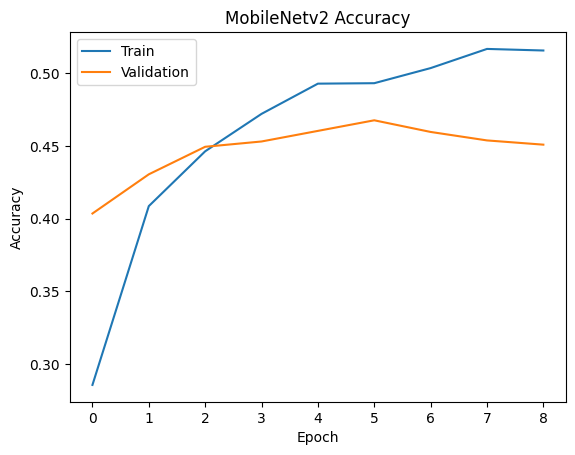

In [ ]:
train_acc = history_mn["train_acc"]
val_acc   = history_mn["val_acc"]

plt.plot(train_acc)
plt.plot(val_acc)
plt.legend(["Train", "Validation"])
plt.title("MobileNetv2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

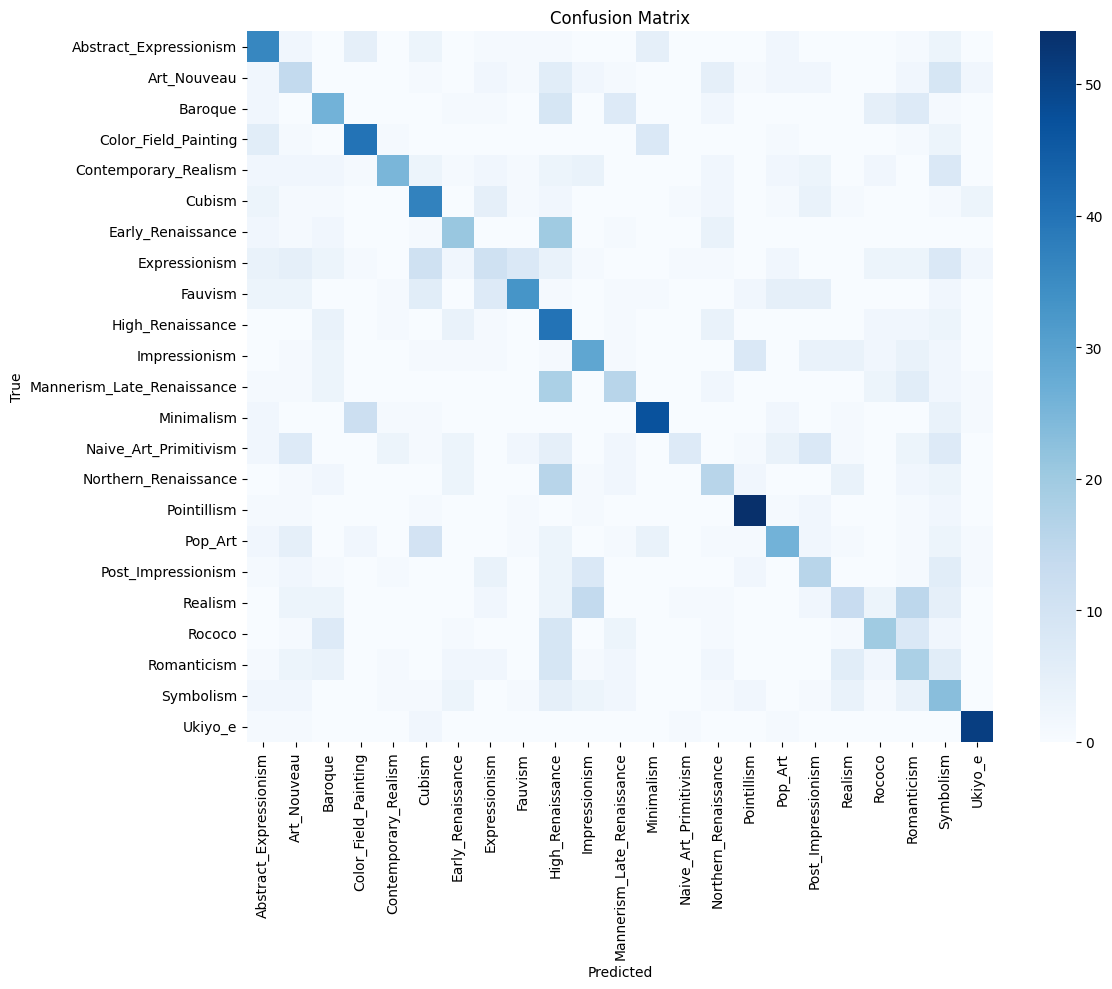

In [ ]:
#Confusion matrix :

class_names = sorted(df_train["style_name"].unique())

cm = compute_confusion_matrix(
    model_mn,
    val_loader,
    device,
    class_names
)

plot_confusion_matrix(cm, class_names)


In [ ]:
class_names = sorted(df_train["style_name"].unique())

acc_per_style = accuracy_per_class(
    model_mn,
    val_loader,
    device,
    class_names
)

results = list(zip(class_names, acc_per_style))
results = sorted(results, key=lambda x: x[1], reverse=True)

for style, acc in results:
    print(f"{style}: {acc:.3f}")


Ukiyo_e: 0.895
Pointillism: 0.831
Minimalism: 0.662
Color_Field_Painting: 0.656
High_Renaissance: 0.645
Abstract_Expressionism: 0.600
Cubism: 0.587
Fauvism: 0.471
Impressionism: 0.468
Baroque: 0.426
Symbolism: 0.411
Pop_Art: 0.406
Early_Renaissance: 0.404
Contemporary_Realism: 0.397
Rococo: 0.377
Post_Impressionism: 0.348
Northern_Renaissance: 0.308
Romanticism: 0.305
Mannerism_Late_Renaissance: 0.302
Art_Nouveau: 0.269
Realism: 0.200
Expressionism: 0.157
Naive_Art_Primitivism: 0.125


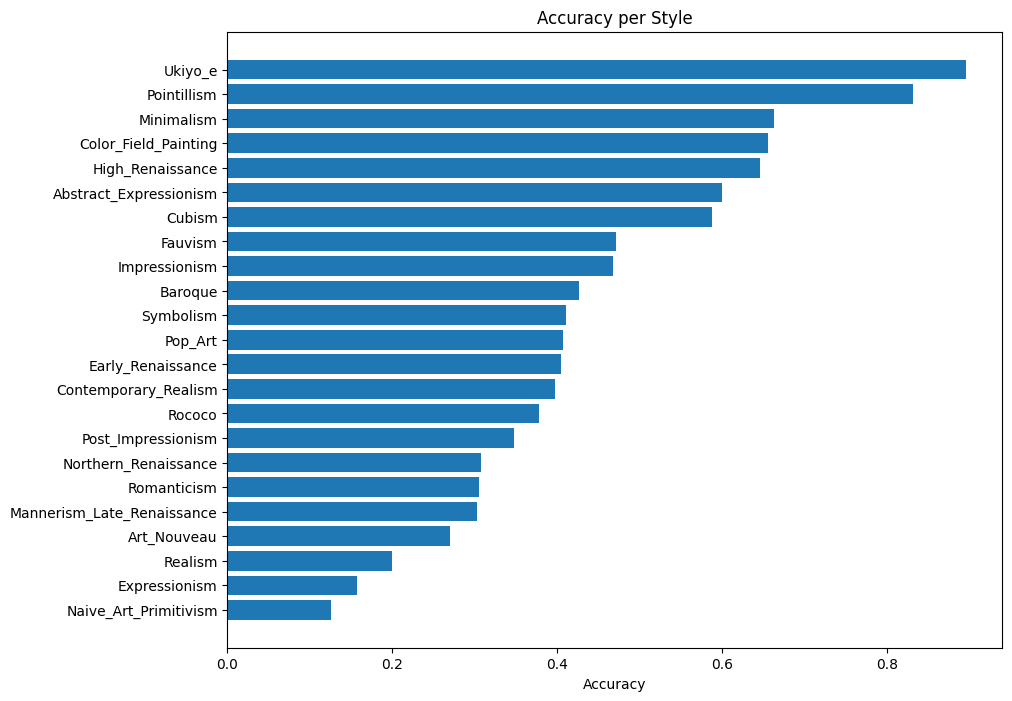

In [ ]:
visualize_accuracy_per_style(results)

#### 1.4 Evaluation sur l'ensemble de test

In [ ]:
best_model_weights = model_mn.state_dict()

test_acc, test_cm, report = evaluate_model(model_mn, test_loader, device)

print(f"Test Accuracy: {test_acc:.3f}")
print("Classification Report:")
print(report)

Test Accuracy: 0.414
Classification Report:
                            precision    recall  f1-score   support

    Abstract_Expressionism     0.3478    0.4898    0.4068        49
               Art_Nouveau     0.2909    0.2909    0.2909        55
                   Baroque     0.3043    0.2333    0.2642        60
      Color_Field_Painting     0.7561    0.6078    0.6739        51
      Contemporary_Realism     0.7273    0.2807    0.4051        57
                    Cubism     0.5000    0.6333    0.5588        60
         Early_Renaissance     0.5745    0.3857    0.4615        70
             Expressionism     0.2903    0.1552    0.2022        58
                   Fauvism     0.5349    0.4182    0.4694        55
          High_Renaissance     0.1957    0.6207    0.2975        58
             Impressionism     0.3766    0.4203    0.3973        69
Mannerism_Late_Renaissance     0.4783    0.3284    0.3894        67
                Minimalism     0.7018    0.7273    0.7143        55
   

Test Confusion Matrix:


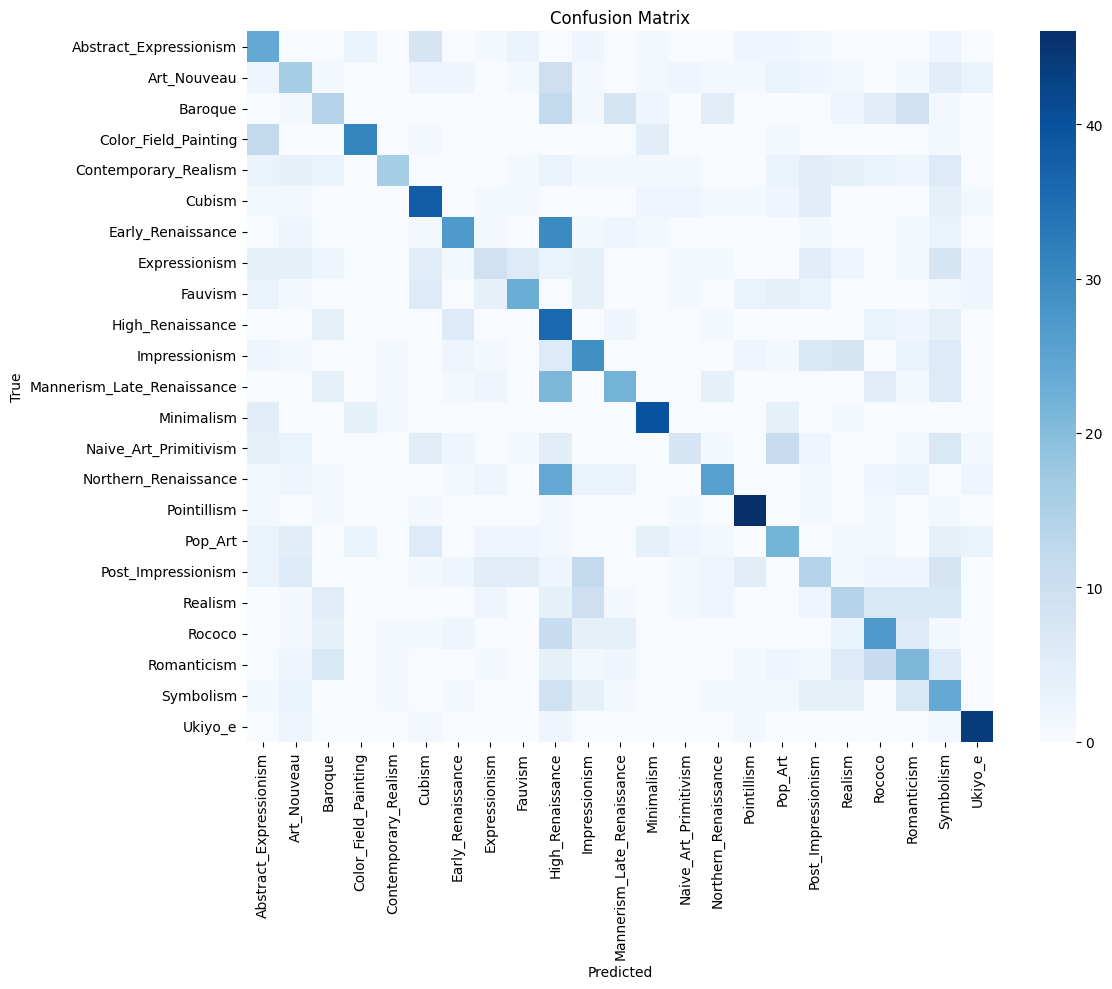

In [ ]:
print("Test Confusion Matrix:")
plot_confusion_matrix(test_cm, class_names)

## 2. MobileNet V3 Small

#### 2.1 Charger le modèle

In [ ]:
num_classes = df_train["style_encoded"].nunique()

model_mn = get_model("mobilenet_v3_small", num_classes=num_classes)
model_mn = model_mn.to(device)

# ajout de label smoothing pour la cross entropy loss
# label smoothing permet de rendre le modèle moins confiant dans ses prédictions,
# ce qui peut aider à améliorer la généralisation et réduire le surapprentissage
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.Adam(
    model_mn.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 93.9MB/s]


#### 2.2 Entrainement

In [ ]:
# from src.utils import EarlyStopping

early_stopping = EarlyStopping(patience=3)

NUM_EPOCHS_FREEZE = 10
history_mn = train_model(
    model_mn,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs=NUM_EPOCHS_FREEZE,
    early_stopping=early_stopping
)



Epoch 1/10


Train Loss: 2.6666 | Train Acc: 0.2391 | Val Loss: 2.3459 | Val Acc: 0.3540

Epoch 2/10


Train Loss: 2.3197 | Train Acc: 0.3570 | Val Loss: 2.2502 | Val Acc: 0.3744

Epoch 3/10


Train Loss: 2.2338 | Train Acc: 0.3887 | Val Loss: 2.2010 | Val Acc: 0.3933

Epoch 4/10


Train Loss: 2.1737 | Train Acc: 0.4018 | Val Loss: 2.1755 | Val Acc: 0.4101

Epoch 5/10


...

Train Loss: 2.1169 | Train Acc: 0.4320 | Val Loss: 2.1443 | Val Acc: 0.4261

Epoch 7/10


Train Loss: 2.0827 | Train Acc: 0.4441 | Val Loss: 2.1406 | Val Acc: 0.4181

Epoch 8/10


Train Loss: 2.0758 | Train Acc: 0.4419 | Val Loss: 2.1411 | Val Acc: 0.4283

Epoch 9/10


Train Loss: 2.0553 | Train Acc: 0.4546 | Val Loss: 2.1248 | Val Acc: 0.4261

Epoch 10/10


Train Loss: 2.0414 | Train Acc: 0.4604 | Val Loss: 2.1186 | Val Acc: 0.4334


#### 2.3 Evaluation

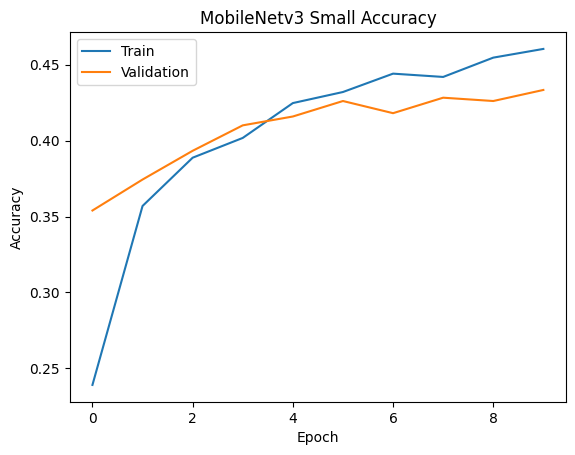

In [ ]:
train_acc = history_mn["train_acc"]
val_acc   = history_mn["val_acc"]

plt.plot(train_acc)
plt.plot(val_acc)
plt.legend(["Train", "Validation"])
plt.title("MobileNetv3 Small Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

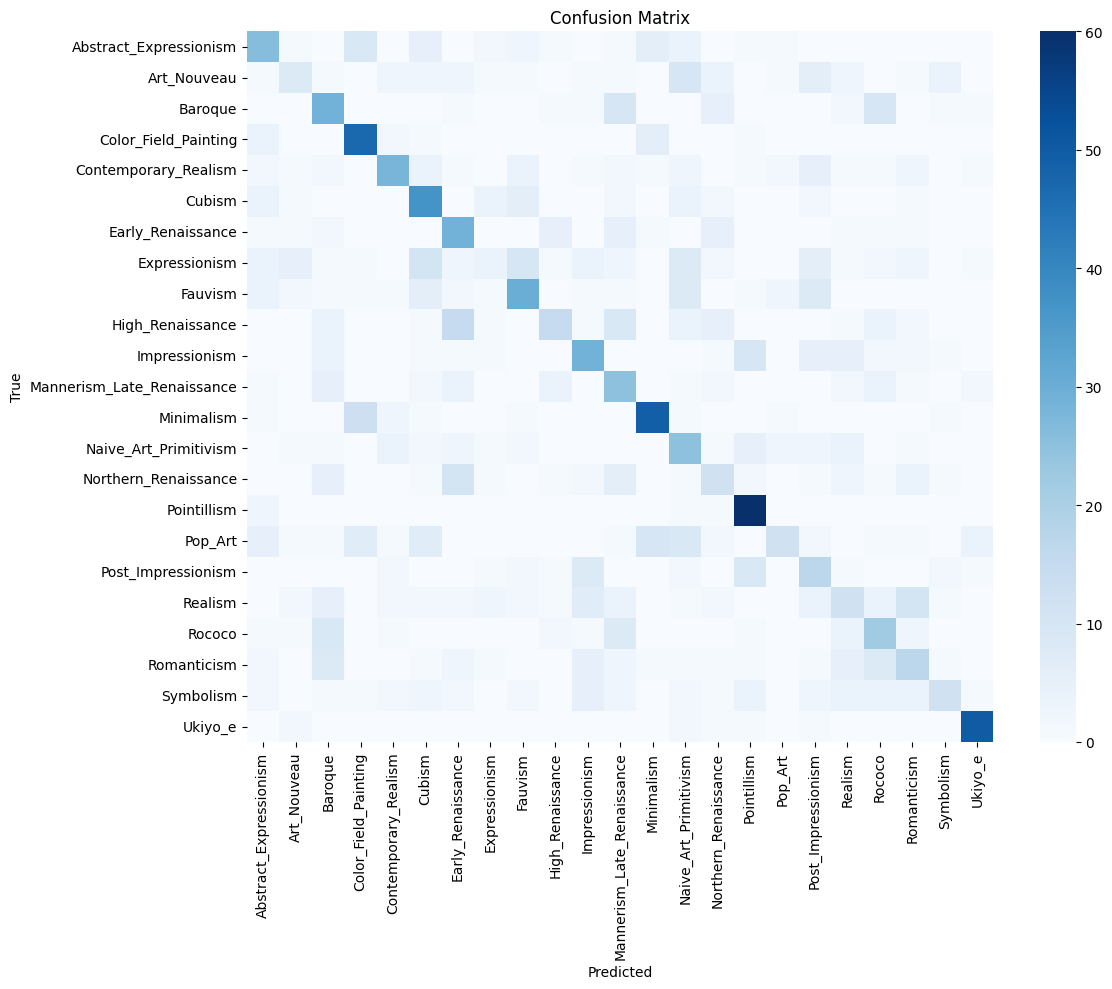

In [ ]:
#Confusion matrix :

class_names = sorted(df_train["style_name"].unique())

cm = compute_confusion_matrix(
    model_mn,
    val_loader,
    device,
    class_names
)

plot_confusion_matrix(cm, class_names)


In [ ]:
class_names = sorted(df_train["style_name"].unique())

acc_per_style = accuracy_per_class(
    model_mn,
    val_loader,
    device,
    class_names
)

results = list(zip(class_names, acc_per_style))
results = sorted(results, key=lambda x: x[1], reverse=True)

for style, acc in results:
    print(f"{style}: {acc:.3f}")


Pointillism: 0.923
Ukiyo_e: 0.877
Color_Field_Painting: 0.770
Minimalism: 0.690
Cubism: 0.587
Early_Renaissance: 0.558
Baroque: 0.475
Mannerism_Late_Renaissance: 0.472
Impressionism: 0.468
Naive_Art_Primitivism: 0.446
Contemporary_Realism: 0.444
Abstract_Expressionism: 0.433
Fauvism: 0.429
Rococo: 0.415
Post_Impressionism: 0.370
Romanticism: 0.288
High_Renaissance: 0.242
Northern_Renaissance: 0.231
Symbolism: 0.214
Pop_Art: 0.188
Realism: 0.185
Art_Nouveau: 0.154
Expressionism: 0.057


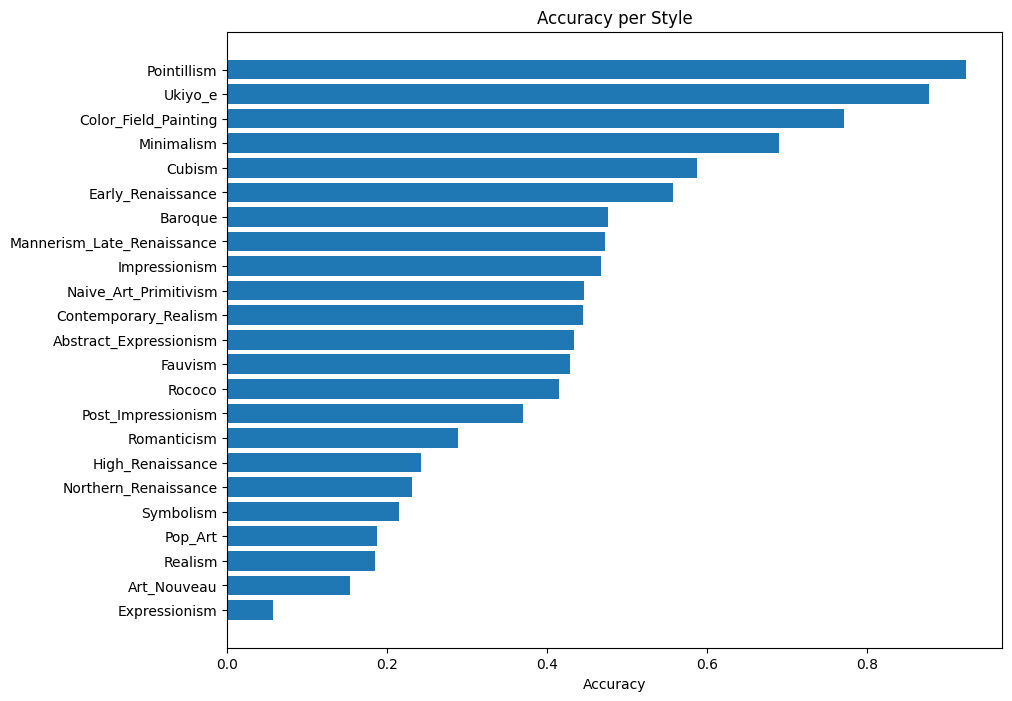

In [ ]:
visualize_accuracy_per_style(results)

#### 2.4 Evaluation sur l'ensemble de test

In [ ]:
best_model_weights = model_mn.state_dict()

test_acc, test_cm, report = evaluate_model(model_mn, test_loader, device)

print(f"Test Accuracy: {test_acc:.3f}")
print("Classification Report:")
print(report)

Test Accuracy: 0.404
Classification Report:
                            precision    recall  f1-score   support

    Abstract_Expressionism     0.3265    0.3265    0.3265        49
               Art_Nouveau     0.3684    0.1273    0.1892        55
                   Baroque     0.3053    0.4833    0.3742        60
      Color_Field_Painting     0.5763    0.6667    0.6182        51
      Contemporary_Realism     0.5588    0.3333    0.4176        57
                    Cubism     0.4487    0.5833    0.5072        60
         Early_Renaissance     0.4405    0.5286    0.4805        70
             Expressionism     0.1875    0.0517    0.0811        58
                   Fauvism     0.4407    0.4727    0.4561        55
          High_Renaissance     0.3030    0.1724    0.2198        58
             Impressionism     0.2895    0.3188    0.3034        69
Mannerism_Late_Renaissance     0.4565    0.6269    0.5283        67
                Minimalism     0.6667    0.7273    0.6957        55
   

Test Confusion Matrix:


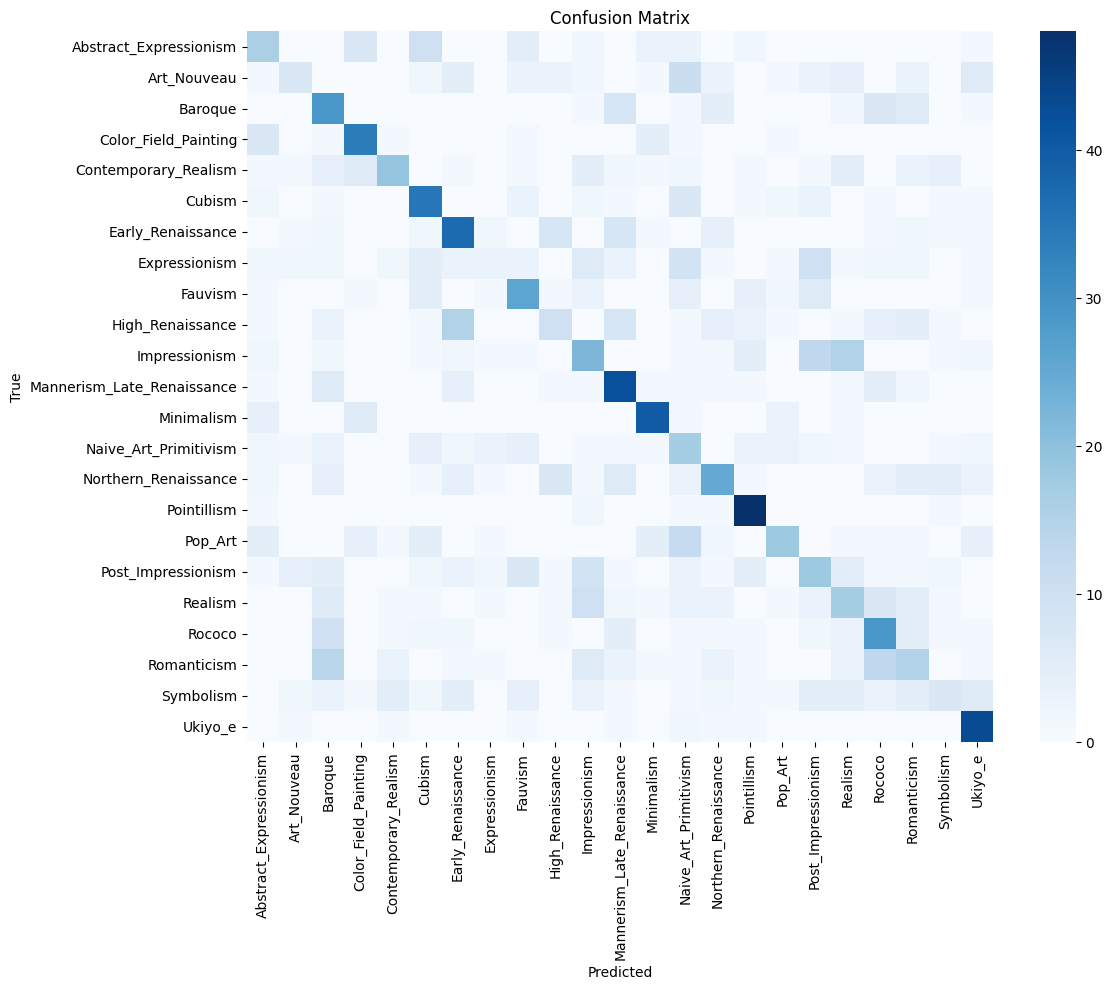

In [ ]:
print("Test Confusion Matrix:")
plot_confusion_matrix(test_cm, class_names)

## 3. MobileNet V3

#### 3.1 Charger le modèle

In [11]:
num_classes = df_train["style_encoded"].nunique()

model_mn = get_model("mobilenet_v3_large", num_classes=num_classes)
model_mn = model_mn.to(device)

# ajout de label smoothing pour la cross entropy loss
# label smoothing permet de rendre le modèle moins confiant dans ses prédictions,
# ce qui peut aider à améliorer la généralisation et réduire le surapprentissage
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.Adam(
    model_mn.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 171MB/s]


#### 3.2 Entrainement

In [12]:
# from src.utils import EarlyStopping

early_stopping = EarlyStopping(patience=3)

NUM_EPOCHS_FREEZE = 10
history_mn = train_model(
    model_mn,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs=NUM_EPOCHS_FREEZE,
    early_stopping=early_stopping
)



Epoch 1/10


Train Loss: 2.5250 | Train Acc: 0.2901 | Val Loss: 2.2024 | Val Acc: 0.4042

Epoch 2/10


Train Loss: 2.1524 | Train Acc: 0.4193 | Val Loss: 2.0824 | Val Acc: 0.4385

Epoch 3/10


Train Loss: 2.0508 | Train Acc: 0.4546 | Val Loss: 2.0431 | Val Acc: 0.4625

Epoch 4/10


Train Loss: 1.9943 | Train Acc: 0.4745 | Val Loss: 2.0518 | Val Acc: 0.4610

Epoch 5/10


...

Train Loss: 1.9305 | Train Acc: 0.5038 | Val Loss: 2.0286 | Val Acc: 0.4734

Epoch 7/10


Train Loss: 1.9080 | Train Acc: 0.5114 | Val Loss: 2.0384 | Val Acc: 0.4538

Epoch 8/10


Train Loss: 1.8788 | Train Acc: 0.5224 | Val Loss: 2.0387 | Val Acc: 0.4661

Epoch 9/10


Train Loss: 1.8620 | Train Acc: 0.5314 | Val Loss: 2.0120 | Val Acc: 0.4749

Epoch 10/10


Train Loss: 1.8356 | Train Acc: 0.5385 | Val Loss: 2.0135 | Val Acc: 0.4720


#### 3.3 Evaluation

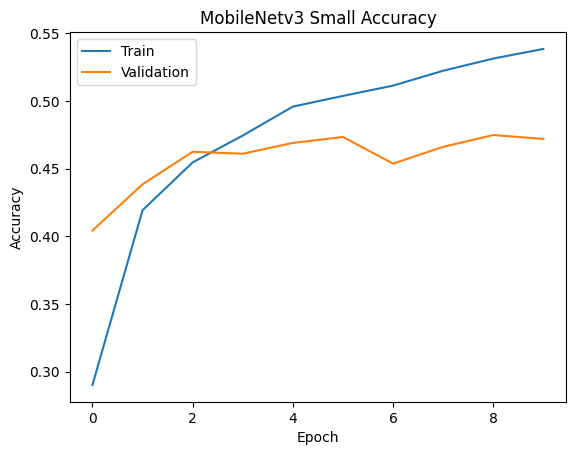

In [13]:
train_acc = history_mn["train_acc"]
val_acc   = history_mn["val_acc"]

plt.plot(train_acc)
plt.plot(val_acc)
plt.legend(["Train", "Validation"])
plt.title("MobileNetv3 Small Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

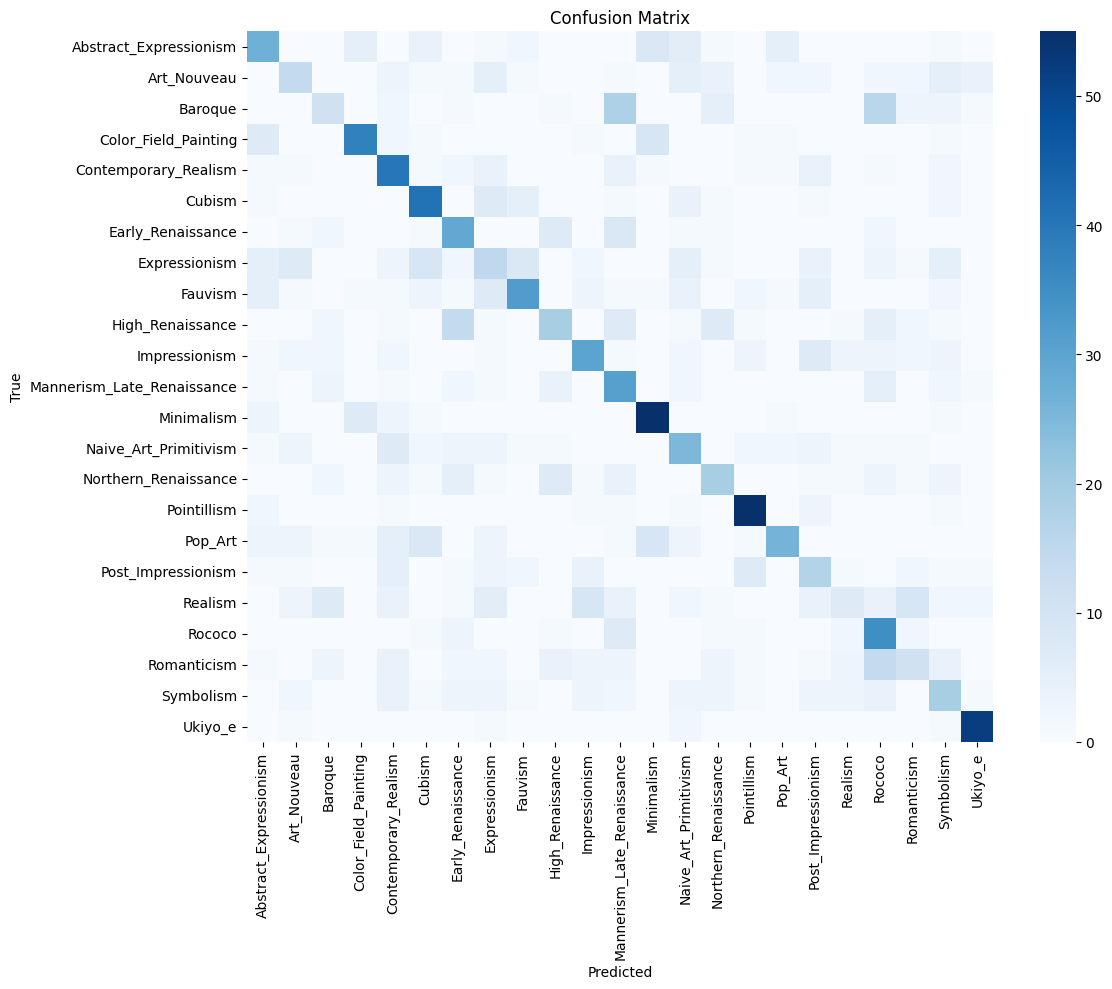

In [14]:
#Confusion matrix :

class_names = sorted(df_train["style_name"].unique())

cm = compute_confusion_matrix(
    model_mn,
    val_loader,
    device,
    class_names
)

plot_confusion_matrix(cm, class_names)


In [15]:
class_names = sorted(df_train["style_name"].unique())

acc_per_style = accuracy_per_class(
    model_mn,
    val_loader,
    device,
    class_names
)

results = list(zip(class_names, acc_per_style))
results = sorted(results, key=lambda x: x[1], reverse=True)

for style, acc in results:
    print(f"{style}: {acc:.3f}")


Ukiyo_e: 0.912
Pointillism: 0.846
Minimalism: 0.775
Rococo: 0.660
Cubism: 0.651
Contemporary_Realism: 0.635
Color_Field_Painting: 0.623
Mannerism_Late_Renaissance: 0.585
Early_Renaissance: 0.558
Impressionism: 0.484
Fauvism: 0.457
Abstract_Expressionism: 0.450
Naive_Art_Primitivism: 0.446
Pop_Art: 0.406
Post_Impressionism: 0.370
Northern_Renaissance: 0.365
Symbolism: 0.339
High_Renaissance: 0.306
Art_Nouveau: 0.269
Expressionism: 0.214
Romanticism: 0.186
Baroque: 0.180
Realism: 0.108


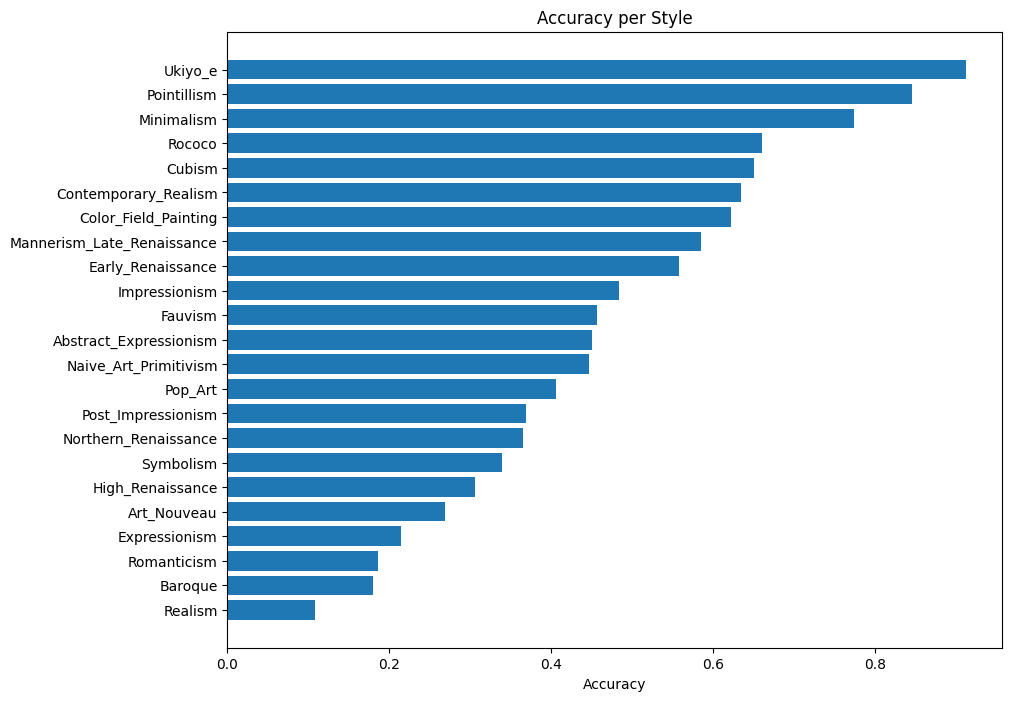

In [16]:
visualize_accuracy_per_style(results)

#### 3.4 Evaluation sur l'ensemble de test

In [17]:
best_model_weights = model_mn.state_dict()

test_acc, test_cm, report = evaluate_model(model_mn, test_loader, device)

print(f"Test Accuracy: {test_acc:.3f}")
print("Classification Report:")
print(report)

Test Accuracy: 0.433
Classification Report:
                            precision    recall  f1-score   support

    Abstract_Expressionism     0.4490    0.4490    0.4490        49
               Art_Nouveau     0.3721    0.2909    0.3265        55
                   Baroque     0.4815    0.2167    0.2989        60
      Color_Field_Painting     0.6829    0.5490    0.6087        51
      Contemporary_Realism     0.3896    0.5263    0.4478        57
                    Cubism     0.5246    0.5333    0.5289        60
         Early_Renaissance     0.4643    0.5571    0.5065        70
             Expressionism     0.2466    0.3103    0.2748        58
                   Fauvism     0.3818    0.3818    0.3818        55
          High_Renaissance     0.3556    0.2759    0.3107        58
             Impressionism     0.4915    0.4203    0.4531        69
Mannerism_Late_Renaissance     0.4343    0.6418    0.5181        67
                Minimalism     0.5890    0.7818    0.6719        55
   

Test Confusion Matrix:


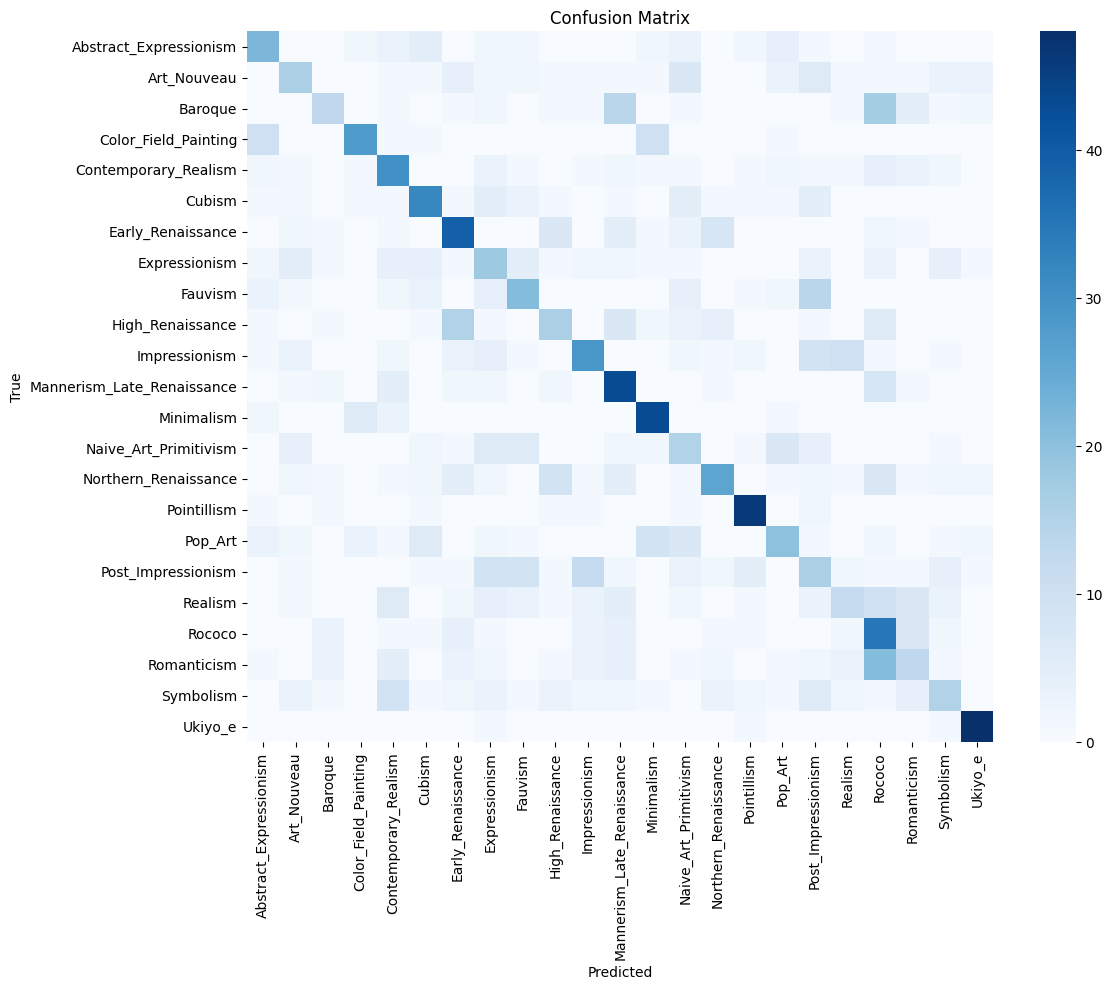

In [18]:
print("Test Confusion Matrix:")
plot_confusion_matrix(test_cm, class_names)

## 4. Ajout de Data Augmentation et finetuning sur MobileNet V3 Large

#### Dataset avec ajout de data augmentation

In [ ]:
transform_train_data_aug = transforms.Compose([
    # On redimensionne un peu plus grand
    transforms.Resize(256),

    # On découpe une zone aléatoire de 224x224
    # Simulation zoom sur les détails du tableau.
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),

    # Retournement horizontal (on inverse gauche/droite)
    transforms.RandomHorizontalFlip(p=0.5),

    # Variations de couleurs légères
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),

    # Conversion et Normalisation
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])


In [ ]:
IMAGE_ROOT_TRAIN = DATA_ROOT / "train"
IMAGE_ROOT_VAL = DATA_ROOT / "val"
IMAGE_ROOT_TEST = DATA_ROOT / "test"

train_dataset_aug = ArtDataset(
    df_train,
    IMAGE_ROOT_TRAIN,
    transform=transform_train_data_aug
)

val_dataset = ArtDataset(
    df_val,
    IMAGE_ROOT_VAL,
    transform=transform_val
)

test_dataset = ArtDataset(
    df_test,
    IMAGE_ROOT_TEST,
    transform=transform_val
)

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0
        self.stop = False

    def step(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

### MobileNet V3 large avec Data augmentation n°1 et entièrement freeze

In [ ]:
num_classes = df_train["style_encoded"].nunique()

model_mn = get_model("mobilenet_v3_large", num_classes=num_classes)
model_mn = model_mn.to(device)

# ajout de label smoothing pour la cross entropy loss
# label smoothing permet de rendre le modèle moins confiant dans ses prédictions,
# ce qui peut aider à améliorer la généralisation et réduire le surapprentissage
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.Adam(
    model_mn.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=3)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 186MB/s]


In [ ]:
# from src.utils import EarlyStopping

early_stopping = EarlyStopping(patience=8)

NUM_EPOCHS_FREEZE = 10
history_mn = train_model(
    model_mn,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs=NUM_EPOCHS_FREEZE,
    early_stopping=early_stopping,
    scheduler=scheduler
)



Epoch 1/10


Train Loss: 2.5288 | Train Acc: 0.2954 | Val Loss: 2.1927 | Val Acc: 0.4079
Current Learning Rate: 0.001

Epoch 2/10


Train Loss: 2.1704 | Train Acc: 0.4092 | Val Loss: 2.0850 | Val Acc: 0.4348
Current Learning Rate: 0.001

Epoch 3/10


Train Loss: 2.0730 | Train Acc: 0.4407 | Val Loss: 2.0386 | Val Acc: 0.4698
Current Learning Rate: 0.001

Epoch 4/10


Train Loss: 2.0278 | Train Acc: 0.4587 | Val Loss: 2.0595 | Val Acc: 0.4436
Current Learning Rate: 0.001

Epoch 5/10


...

Train Loss: 1.9635 | Train Acc: 0.4861 | Val Loss: 2.0353 | Val Acc: 0.4734
Current Learning Rate: 0.001

Epoch 7/10


Train Loss: 1.9484 | Train Acc: 0.4900 | Val Loss: 2.0514 | Val Acc: 0.4479
Current Learning Rate: 0.001

Epoch 8/10


Train Loss: 1.9222 | Train Acc: 0.5002 | Val Loss: 2.0529 | Val Acc: 0.4596
Current Learning Rate: 0.001

Epoch 9/10


Train Loss: 1.9051 | Train Acc: 0.5137 | Val Loss: 2.0128 | Val Acc: 0.4792
Current Learning Rate: 0.001

Epoch 10/10


Train Loss: 1.8914 | Train Acc: 0.5112 | Val Loss: 2.0323 | Val Acc: 0.4785
Current Learning Rate: 0.001


In [ ]:
torch.save(model_mn.state_dict(), "mobilenet_v3_phase1_47acc.pth")

Evaluation sur l'ensemble de test :

In [ ]:
best_model_weights = model_mn.state_dict()

test_acc, test_cm, report = evaluate_model(model_mn, test_loader, device)

print(f"Test Accuracy: {test_acc:.3f}")
print("Classification Report:")
print(report)

Test Accuracy: 0.433
Classification Report:
                            precision    recall  f1-score   support

    Abstract_Expressionism     0.4706    0.4898    0.4800        49
               Art_Nouveau     0.3462    0.3273    0.3364        55
                   Baroque     0.4643    0.2167    0.2955        60
      Color_Field_Painting     0.7692    0.5882    0.6667        51
      Contemporary_Realism     0.4000    0.4561    0.4262        57
                    Cubism     0.5606    0.6167    0.5873        60
         Early_Renaissance     0.4455    0.6429    0.5263        70
             Expressionism     0.2468    0.3276    0.2815        58
                   Fauvism     0.5714    0.2909    0.3855        55
          High_Renaissance     0.4412    0.2586    0.3261        58
             Impressionism     0.6667    0.2899    0.4040        69
Mannerism_Late_Renaissance     0.4853    0.4925    0.4889        67
                Minimalism     0.5789    0.8000    0.6718        55
   

### MobileNet V3 large avec Data augmentation n°1 et finetuning (les 3 dernières couches unfreeze)

In [ ]:
from src.train import train_model, unfreeze_last_layers, unfreeze_all


In [ ]:
num_classes = df_train["style_encoded"].nunique()

model_mn = get_model("mobilenet_v3_large", num_classes=num_classes)
model_mn = model_mn.to(device)
model_mn.load_state_dict(torch.load("/content/mobilenet_v3_phase1_47acc.pth",weights_only=True))
print("Poids phase 1 (tout freeze) chargés")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

model_mn = unfreeze_last_layers(model_mn, "mobilenet_v3_large", num_blocks=3)

optimizer_p2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_mn.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler_p2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2, mode='min', factor=0.3, patience=2
)


Poids phase 1 (tout freeze) chargés
Paramètres entraînables : 1,772,343 / 2,994,055 (59.2%)


In [ ]:
history_p2 = train_model(
    model_mn, train_loader, val_loader,
    criterion, optimizer_p2, device,
    num_epochs=20,
    early_stopping=EarlyStopping(patience=8),
    scheduler=scheduler_p2
)



Epoch 1/20


Train Loss: 1.8192 | Train Acc: 0.5477 | Val Loss: 1.9507 | Val Acc: 0.5025
Current Learning Rate: 0.0001

Epoch 2/20


Train Loss: 1.6941 | Train Acc: 0.5984 | Val Loss: 1.9130 | Val Acc: 0.5171
Current Learning Rate: 0.0001

Epoch 3/20


Train Loss: 1.5948 | Train Acc: 0.6430 | Val Loss: 1.9145 | Val Acc: 0.5127
Current Learning Rate: 0.0001

Epoch 4/20


Train Loss: 1.5203 | Train Acc: 0.6741 | Val Loss: 1.8938 | Val Acc: 0.5251
Current Learning Rate: 0.0001

Epoch 5/20


...

Train Loss: 1.2109 | Train Acc: 0.8238 | Val Loss: 1.9064 | Val Acc: 0.5273
Current Learning Rate: 3e-05

Epoch 9/20


Train Loss: 1.1960 | Train Acc: 0.8299 | Val Loss: 1.9046 | Val Acc: 0.5295
Current Learning Rate: 3e-05

Epoch 10/20


Train Loss: 1.1757 | Train Acc: 0.8420 | Val Loss: 1.9166 | Val Acc: 0.5244
Current Learning Rate: 9e-06

Epoch 11/20


Train Loss: 1.1563 | Train Acc: 0.8496 | Val Loss: 1.9182 | Val Acc: 0.5229
Current Learning Rate: 9e-06

Epoch 12/20


Train Loss: 1.1351 | Train Acc: 0.8645 | Val Loss: 1.9236 | Val Acc: 0.5222
Current Learning Rate: 9e-06
Early stopping triggered.
Meilleur modèle restauré (val_loss=1.8938)


In [ ]:
torch.save(model_mn.state_dict(), "/content/mobilenet_v3_phase2_unfreeze3.pth")


On observe que notre modèle est en surapprentissage, nous allons donc tester d'augmenter encore le nombre de données

### MobileNet V3 large avec Data augmentation n°2 et finetuning (les 3 dernières couches unfreeze)

On ajoute de l'augmentation de données :

In [ ]:
transform_train_data_aug_2 = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
        transforms.RandomErasing(p=0.1),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])


In [ ]:
IMAGE_ROOT_TRAIN = DATA_ROOT / "train"
IMAGE_ROOT_VAL = DATA_ROOT / "val"
IMAGE_ROOT_TEST = DATA_ROOT / "test"

train_dataset_aug_2 = ArtDataset(
    df_train,
    IMAGE_ROOT_TRAIN,
    transform=transform_train_data_aug_2
)

val_dataset = ArtDataset(
    df_val,
    IMAGE_ROOT_VAL,
    transform=transform_val
)

test_dataset = ArtDataset(
    df_test,
    IMAGE_ROOT_TEST,
    transform=transform_val
)

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset_aug_2,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0
        self.stop = False

    def step(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

In [ ]:
num_classes = df_train["style_encoded"].nunique()

model_mn = get_model("mobilenet_v3_large", num_classes=num_classes)
model_mn = model_mn.to(device)
model_mn.load_state_dict(torch.load("/content/mobilenet_v3_phase1_47acc.pth",weights_only=True))
print("Poids phase 1 (tout freeze) chargés")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

model_mn = unfreeze_last_layers(model_mn, "mobilenet_v3_large", num_blocks=3)

optimizer_p2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_mn.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler_p2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2, mode='min', factor=0.3, patience=2
)


Poids phase 1 (tout freeze) chargés
Paramètres entraînables : 1,772,343 / 2,994,055 (59.2%)


In [ ]:
history_p2 = train_model(
    model_mn, train_loader, val_loader,
    criterion, optimizer_p2, device,
    num_epochs=20,
    early_stopping=EarlyStopping(patience=5),
    scheduler=scheduler_p2
)

torch.save(model_mn.state_dict(), "/content/mobilenet_v3_phase2_unfreeze3_data_aug.pth")



Epoch 1/20


Train Loss: 1.9246 | Train Acc: 0.5026 | Val Loss: 1.9813 | Val Acc: 0.4873
Current Learning Rate: 0.0001

Epoch 2/20


Train Loss: 1.8132 | Train Acc: 0.5503 | Val Loss: 1.9381 | Val Acc: 0.5047
Current Learning Rate: 0.0001

Epoch 3/20


Train Loss: 1.7287 | Train Acc: 0.5844 | Val Loss: 1.9316 | Val Acc: 0.5040
Current Learning Rate: 0.0001

Epoch 4/20


Train Loss: 1.6596 | Train Acc: 0.6137 | Val Loss: 1.9203 | Val Acc: 0.5047
Current Learning Rate: 0.0001

Epoch 5/20


...

Train Loss: 1.5318 | Train Acc: 0.6725 | Val Loss: 1.9242 | Val Acc: 0.5164
Current Learning Rate: 0.0001

Epoch 7/20


Train Loss: 1.4639 | Train Acc: 0.7045 | Val Loss: 1.9132 | Val Acc: 0.5229
Current Learning Rate: 0.0001

Epoch 8/20


Train Loss: 1.4133 | Train Acc: 0.7212 | Val Loss: 1.9240 | Val Acc: 0.5193
Current Learning Rate: 3e-05

Epoch 9/20


Train Loss: 1.3460 | Train Acc: 0.7544 | Val Loss: 1.9190 | Val Acc: 0.5208
Current Learning Rate: 3e-05

Epoch 10/20


Train Loss: 1.3305 | Train Acc: 0.7624 | Val Loss: 1.9242 | Val Acc: 0.5157
Current Learning Rate: 3e-05
Early stopping triggered.
Meilleur modèle restauré (val_loss=1.9123)


Les valeurs d'accuracy sur la partie validation ne se sont pas spécialement améliorées mais on a réduit le surapprentissage. 

### MobileNet V3 large avec Data augmentation n°2 et toutes les couches unfreeze

In [ ]:
num_classes = df_train["style_encoded"].nunique()
model_mn = get_model("mobilenet_v3_large", num_classes=num_classes)
model_mn = model_mn.to(device)
model_mn.load_state_dict(torch.load("/content/mobilenet_v3_phase2_unfreeze3_data_aug.pth", weights_only=True))
print("Poids phase 2 v2 (avec data augmentation forte)")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# On dégèle tout
model_mn = unfreeze_all(model_mn)

# On utilise un optimizer avec LR très faible
optimizer_p3 = torch.optim.Adam(
    model_mn.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

scheduler_p3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p3, mode='min', factor=0.3, patience=2
)


Poids phase 2 v2 (avec data augmentation forte)
Tous les paramètres dégelés : 2,994,055


In [ ]:
history_p3 = train_model(
    model_mn, train_loader, val_loader,
    criterion, optimizer_p3, device,
    num_epochs=20,
    early_stopping=EarlyStopping(patience=5),
    scheduler=scheduler_p3
)

torch.save(model_mn.state_dict(), "/content/mobilenet_v3_phase3_unfreeze_all.pth")


Epoch 1/20


Train Loss: 1.5105 | Train Acc: 0.6796 | Val Loss: 1.8918 | Val Acc: 0.5237
Current Learning Rate: 1e-05

Epoch 2/20


Train Loss: 1.4826 | Train Acc: 0.6869 | Val Loss: 1.8944 | Val Acc: 0.5259
Current Learning Rate: 1e-05

Epoch 3/20


Train Loss: 1.4503 | Train Acc: 0.7065 | Val Loss: 1.8890 | Val Acc: 0.5280
Current Learning Rate: 1e-05

Epoch 4/20


Train Loss: 1.4455 | Train Acc: 0.7088 | Val Loss: 1.8878 | Val Acc: 0.5273
Current Learning Rate: 1e-05

Epoch 5/20


...

Train Loss: 1.3670 | Train Acc: 0.7486 | Val Loss: 1.8669 | Val Acc: 0.5288
Current Learning Rate: 1e-05

Epoch 11/20


Train Loss: 1.3601 | Train Acc: 0.7542 | Val Loss: 1.8672 | Val Acc: 0.5346
Current Learning Rate: 1e-05

Epoch 12/20


Train Loss: 1.3348 | Train Acc: 0.7663 | Val Loss: 1.8683 | Val Acc: 0.5368
Current Learning Rate: 3e-06

Epoch 13/20


Train Loss: 1.3313 | Train Acc: 0.7662 | Val Loss: 1.8668 | Val Acc: 0.5390
Current Learning Rate: 3e-06

Epoch 14/20


Train Loss: 1.3277 | Train Acc: 0.7649 | Val Loss: 1.8686 | Val Acc: 0.5397
Current Learning Rate: 3e-06
Early stopping triggered.
Meilleur modèle restauré (val_loss=1.8665)


Affichage de la matrice de confusion pour le rapport :

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 208MB/s]


Modèle chargé
Test Accuracy : 0.501
                            precision    recall  f1-score   support

    Abstract_Expressionism     0.5000    0.4694    0.4842        49
               Art_Nouveau     0.3148    0.3091    0.3119        55
                   Baroque     0.4386    0.4167    0.4274        60
      Color_Field_Painting     0.7347    0.7059    0.7200        51
      Contemporary_Realism     0.5660    0.5263    0.5455        57
                    Cubism     0.5672    0.6333    0.5984        60
         Early_Renaissance     0.5897    0.6571    0.6216        70
             Expressionism     0.2769    0.3103    0.2927        58
                   Fauvism     0.5500    0.4000    0.4632        55
          High_Renaissance     0.5094    0.4655    0.4865        58
             Impressionism     0.5610    0.3333    0.4182        69
Mannerism_Late_Renaissance     0.6471    0.4925    0.5593        67
                Minimalism     0.6949    0.7455    0.7193        55
     Naive_

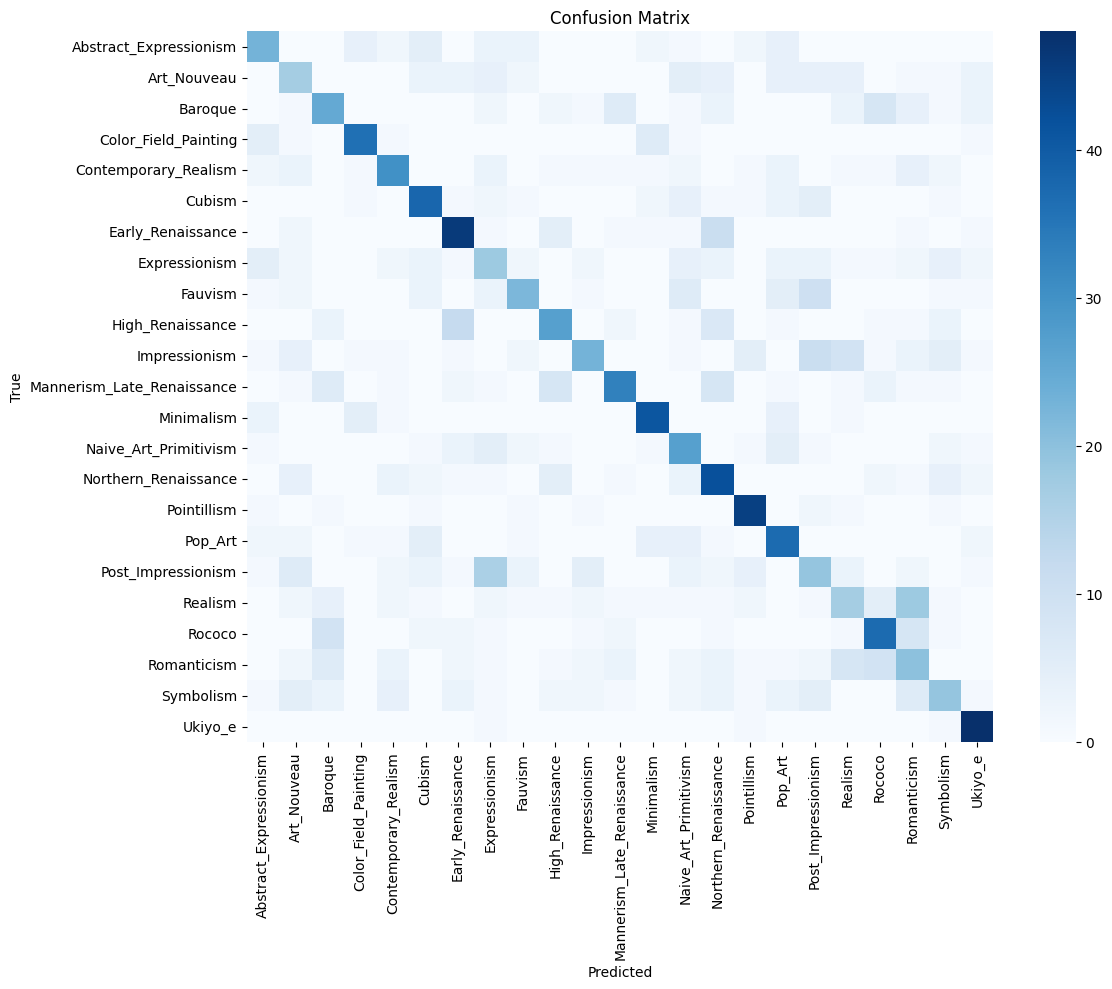

In [ ]:
from src.models import get_model
from src.evaluate import evaluate_model, plot_confusion_matrix

transform_std = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

num_classes = df_test["style_encoded"].nunique()

model_mobilenet = get_model(
    model_name="mobilenet_v3_large",
    num_classes=num_classes,
    dropout_p=0.2,
    freeze_backbone=False  # finetuné donc tout dégelé
)
model_mobilenet = model_mobilenet.to(device)

checkpoint = torch.load(
    "/content/mobilenet_v3_phase3_unfreeze_all.pth",
    weights_only=True
)

model_mobilenet.load_state_dict(checkpoint)

print("Modèle chargé")

test_dataset = ArtDataset(df_test, IMAGE_ROOT_TEST, transform=transform_std)
test_loader  = DataLoader(test_dataset, batch_size=32,
                          shuffle=False, num_workers=0)

class_names = sorted(df_test["style_name"].unique())

acc, cm, report = evaluate_model(model_mobilenet, test_loader, device)
print(f"Test Accuracy : {acc:.3f}")
print(report)

plot_confusion_matrix(cm, class_names)